# Week 7 - Temporal models 

## Part 2: Road traffic - Time-series forecasting

In this part, we will specify a simple linear dynamical system (LDS) in Pyro in order to forecast freeway occupancy rates. 

The usual imports...

In [10]:
# Install Pyro, if necessary
!pip install pyro-ppl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import math
import torch
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.contrib.examples.bart import load_bart_od
from pyro.contrib.forecast import ForecastingModel, Forecaster, eval_crps
from pyro.infer.reparam import LinearHMMReparam, StableReparam, SymmetricStableReparam
from pyro.ops.tensor_utils import periodic_repeat
from pyro.ops.stats import quantile
import matplotlib.pyplot as plt

import time

# fix MCMCndom generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib style options
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

The data consists of time-series of freeway occupancy rates (rows) every 10-minutes, with length $T=1008$, at 10 different consecutive sensors/detectors (columns). However, for now, we will focus only on the data from a single detector as an example...

Load data:

In [12]:
df = pd.read_csv("./PeMS_sample.csv")
df.head()

,# detector400000,detector400001,detector400009,detector400010,detector400015,detector400017,detector400025,detector400026,detector400027,detector400030
0,0.0154,0.0054,0.0164,0.0079,0.0059,0.0138,0.0111,0.0156,0.0154,0.0080
1,0.0085,0.0051,0.0127,0.0062,0.0051,0.0125,0.0099,0.0175,0.0134,0.0067
2,0.0099,0.0056,0.0172,0.0068,0.0053,0.0116,0.0105,0.0157,0.0112,0.0065
3,0.0108,0.0045,0.0126,0.0072,0.0058,0.0131,0.0073,0.0146,0.0128,0.0040
4,0.0100,0.0037,0.0185,0.0048,0.0063,0.0099,0.0061,0.0157,0.0123,0.0064


Some basic data statistics:

In [13]:
print("Dataset size:", len(df))
print("General statistics:")
df.describe()

Dataset size: 1008
General statistics:


,# detector400000,detector400001,detector400009,detector400010,detector400015,detector400017,detector400025,detector400026,detector400027,detector400030
count,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.00000,1008.000000
mean,0.049489,0.044541,0.066207,0.051599,0.026812,0.047976,0.037051,0.055881,0.05583,0.049262
std,0.030016,0.047490,0.047321,0.040934,0.019402,0.052455,0.036248,0.049275,0.04192,0.042152
min,0.005300,0.000000,0.000000,0.000000,0.001900,0.002200,0.002900,0.002500,0.00150,0.001500
25%,0.027150,0.014900,0.029525,0.018000,0.013100,0.014775,0.012075,0.017950,0.01820,0.027075
50%,0.055300,0.038600,0.070500,0.046400,0.021700,0.038750,0.029000,0.051500,0.05665,0.046700
75%,0.064400,0.051900,0.088025,0.070800,0.030925,0.054125,0.045400,0.069825,0.07670,0.058925
max,0.317600,0.355000,0.393600,0.232700,0.094900,0.316900,0.197200,0.307400,0.22060,0.408100


Visualize data (part of it):

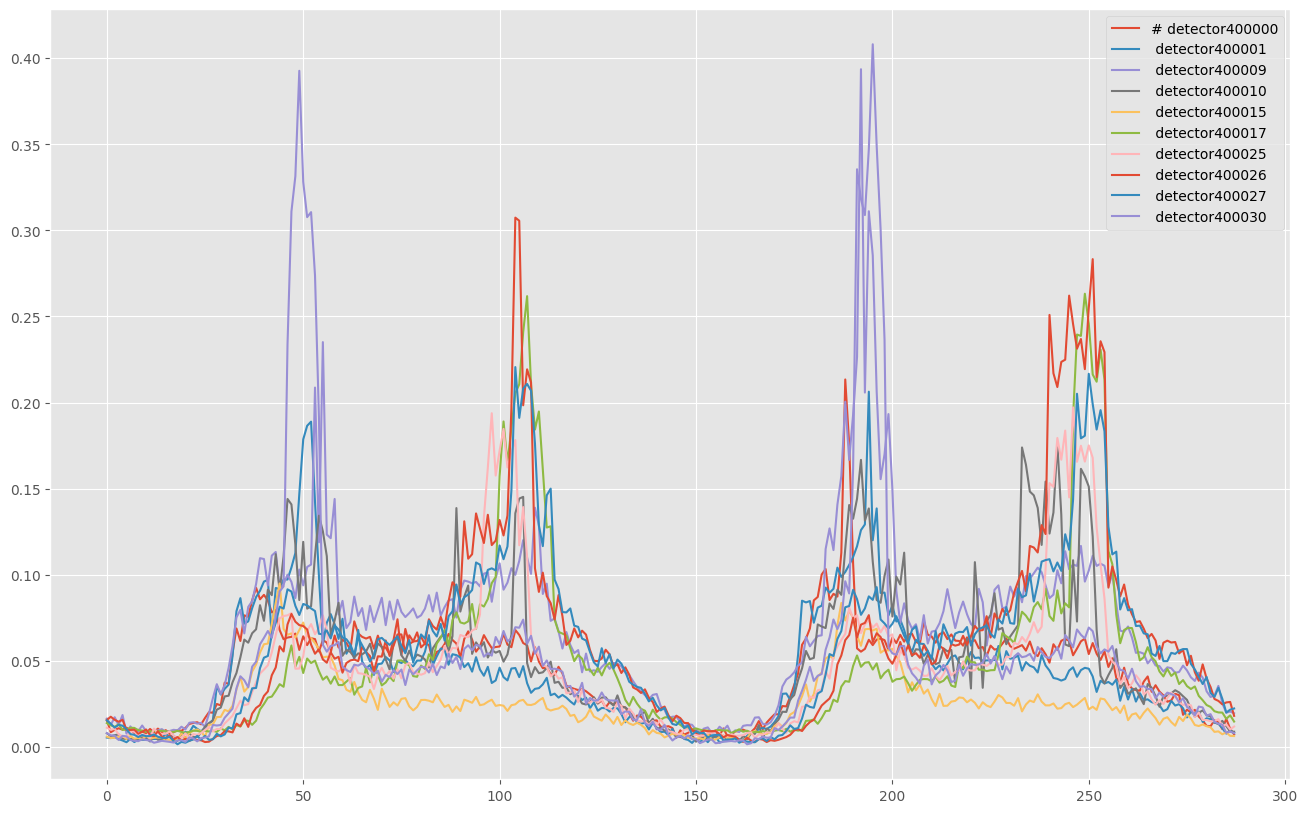

In [14]:
plt.plot(df[:(2*24*6)]); # first 2 days (2*24*6 10-minute intervals) of each of the 10 detectors
plt.legend(df.columns);

Split data into a trainset and a testset (which we wish to forecast):

In [15]:
# convert data to a matrix
y = df.values
N, D = y.shape
print("N=%d, D=%d" % (N,D))

T0 = 0 # start time of the training data
T1 = 6*24*6 # training data ends here (6 days of data)
T2 = 6*24*6 + 12 # test data ends here (12 time-steps ahead forecast)

ix_train = range(T0, T1)
ix_test = range(T1, T2)
N_train = len(ix_train)
N_test = len(ix_test)
print("N_train:", N_train)
print("N_test:", N_test)
y = torch.tensor(y).float()

N=1008, D=10
N_train: 864
N_test: 12


Ok, time to specify our time-series model in Pyro!

For simplicty, we will start with a simple autoregressive model of order 1, AR(1), of the form:

\begin{align}
z_t &\sim \mathcal{N}(\beta_1 z_{t-1}, \tau^2)\\
y_t &\sim \mathcal{N}(z_t, \sigma^2)
\end{align}

Let's call this **Model1**. 

However, the model specified above only allows us to model the local trend in the data. If you look at the plots of the data above, you will realize that the time-series are highly periodic. This aligns with our domain knowledge: traffic is highly recurrent - we know what to expect the traffic to be downtown on Mondays at 9am, as opposed to 2am. Therefore, we would like to include in the AR(1) model above a seasonal. One way to achieve that is by modifying the model as follows (let's call this **Model2**):

\begin{align}
z_t &\sim \mathcal{N}(\beta_1 z_{t-1}, \tau^2)\\
y_t &\sim \mathcal{N}(z_t \color{red} + h_t \color{black}, \sigma^2)
\end{align}

where we introduced a new deterministic term $h_t$ corresponding to how time $t$ looks-like on average based on the historical data. We commonly refer to this as the historical average, as we can compute it easily as follows:

In [16]:
historical_average = y[T0:T1 // (24*6) * 24*6,0].reshape(-1, 24*6).mean(0) # this how an average day in the training data looks like
#historical_average = torch.zeros_like(historical_average) # in case you want to try removing the historical average component from the model used this line instead
historical_average_std = y[T0:T1 // (24*6) * 24*6,0].reshape(-1, 24*6).std(0) # we can also compute the standard deviation of the historical average...

Let's see how it looks like:

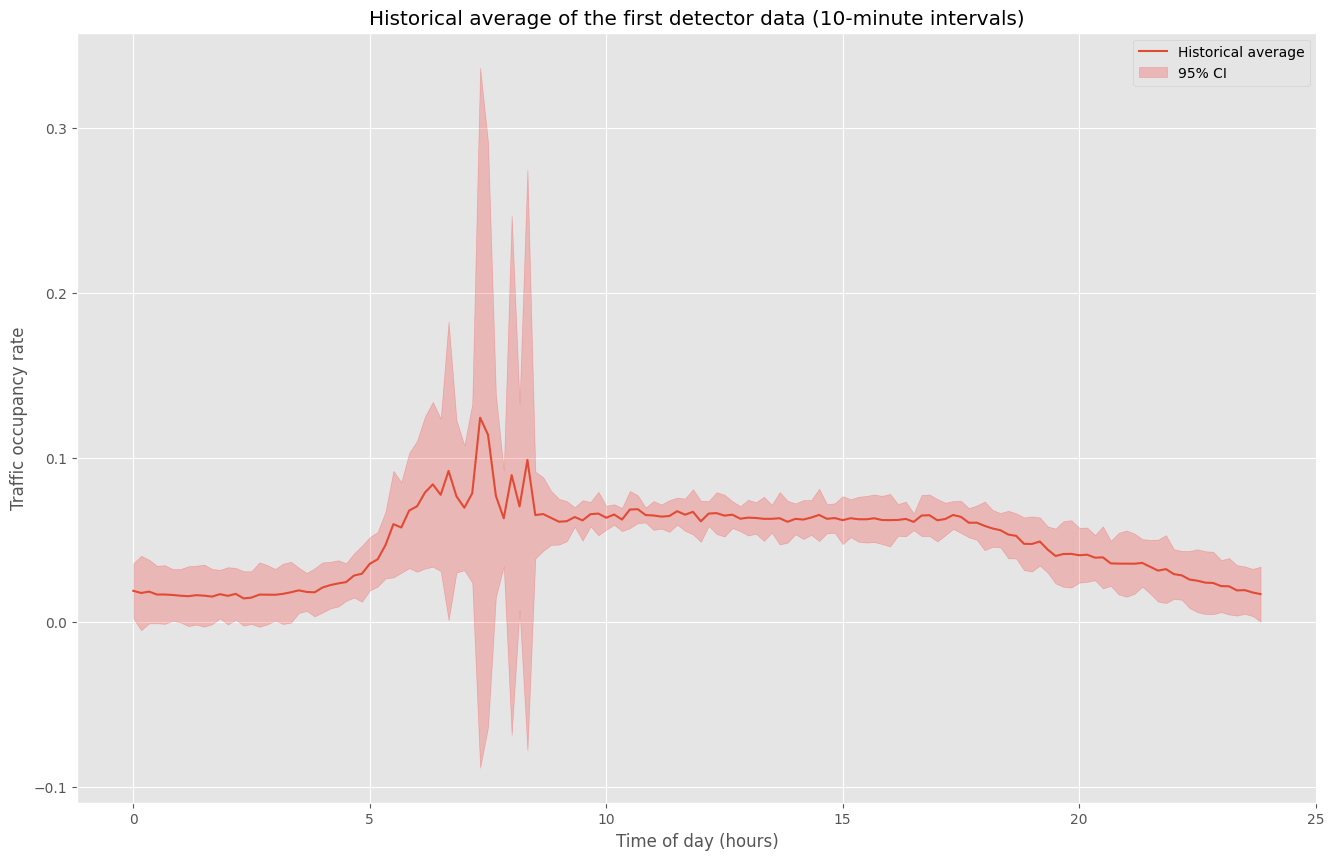

In [17]:
plt.plot(np.arange(0,24,1/6), historical_average);
plt.fill_between(np.arange(0,24,1/6), historical_average - 2*historical_average_std, historical_average + 2*historical_average_std, alpha=0.2, color='red');
plt.title("Historical average of the first detector data (10-minute intervals)")
plt.xlabel("Time of day (hours)");
plt.ylabel("Traffic occupancy rate");
plt.legend(["Historical average", "95% CI"]);

Pyro includes a specialized built-in framework for time-series models. The key reason for this is that doing Bayesian inference in temporal models is often challenging (especially for black-box inference engines such as those that Pyro used by default). By using the provided forecast modules of Pyro ([pyro.contrib.forecast](http://docs.pyro.ai/en/latest/contrib.forecast.html)), it can leverage specialized inference techniques for temporal models (if you studied Kalman filters before, these are the forward and backward recursions that allow for perfoming exact Bayesian inference efficiently in linear-Gaussian temporal models such as this one). 

Pyro's forecasting framework consists of:
- a [ForecastingModel](http://docs.pyro.ai/en/latest/contrib.forecast.html#pyro.contrib.forecast.forecaster.ForecastingModel) base class, whose ``.model()`` method can be implemented for custom forecasting models,
- a [Forecaster](http://docs.pyro.ai/en/latest/contrib.forecast.html#pyro.contrib.forecast.forecaster.Forecaster) class that trains and forecasts using ``ForecastingModel``s, and

We start with some boilerplate for the [ForecastingModel](http://docs.pyro.ai/en/latest/contrib.forecast.html#pyro.contrib.forecast.forecaster.ForecastingModel) base class:

In [18]:
class ModelBoilerplate(ForecastingModel):
    def model(self, zero_data, covariates):
        # Notice the inputs to the model are zero_data and covariates. 
        # zero_data is a tensor with the same shape of the real data, but filled with zeros. This is useful for retrieving data shapes and sizes.
        # covariates can be used to include additional (time-dependent) inputs to the model. In this case we don't use them.
        
        # Now here we would implement our model...
        mean_prediction = None
        noise_dist = None
        
        # The forecast framework requires our model implementation to end with a call to the "predict" method provided by the framework.
        # It takes as input the noise distribution for y_t and a mean prediction tensor (corresponding to h_t in the periodic version of the AR(1) model specification above).
        self.predict(noise_dist, mean_prediction)

We will start by implemening **Model1** - the basic AR(1) version without the periodic component (historical average):

\begin{align}
z_t &\sim \mathcal{N}(\beta_1 z_{t-1}, \tau^2)\\
y_t &\sim \mathcal{N}(z_t, \sigma^2)
\end{align}

For this implementation, we will make use the class [GaussianHMM](https://docs.pyro.ai/en/stable/distributions.html#pyro.distributions.GaussianHMM) to specify our noise distribution (``noise_dist``): 

``noise_dist = dist.GaussianHMM(init_dist, trans_matrix, trans_dist, obs_matrix, obs_dist)``

It takes as input:
- ``init_dist`` - the initial distribution for $z_0$
- ``trans_matrix`` - the transition matrix between states (in our univariate case, that is just $\beta_1$)
- ``trans_dist`` - the noise of the transition distribution for $z_t$ (in our case: $\mathcal{N}(0,\tau^2)$)
- ``obs_matrix`` - the observation matrix that gets multiplied by $z_t$ (in our case that is just the identity matrix)
- ``obs_dist`` - the noise of the emission distribution for $y_t$ (in our case: $\mathcal{N}(0,\sigma^2)$)

The resulting distribution ``noise_dist`` is then the distribution of $y_t$ according to the basic AR(1) model above. 

Let's code it in Pyro. Note that while this example is univariate, Pyro's forecasting framework is multivariate, so we'll often need to reshape using `.unsqueeze(-1)`, `.expand([1])`, and `.to_event(1)`. Make sure that you understand the following piece of code. If you have questions, don't hesitate to ask a teacher or TA for clarifications!

In [19]:
class Model1(ForecastingModel):
    def model(self, zero_data, covariates):
        duration = zero_data.size(-2)
        
        mean_prediction = torch.zeros(zero_data.shape) # in this version of the model, the mean prediction is just zero - i.e., no periodic component
        
        # On top of this mean prediction, we'll learn a linear dynamical system.
        # This requires specifying five pieces of data, on which we will put structured priors.
        init_dist = dist.Normal(torch.zeros(1), 1).to_event(1) 

        trans_matrix = pyro.sample("timescale", dist.Normal(torch.ones(1,1), 1).to_event(2))

        
        trans_scale = pyro.sample("trans_scale", dist.HalfNormal(torch.ones(1)).to_event(1)) 
        trans_dist = dist.Normal(torch.zeros(1), trans_scale).to_event(1)

        # Note the obs_matrix has shape hidden_dim x obs_dim = 1 x 1.
        obs_matrix = torch.eye(1)
        obs_scale = pyro.sample("obs_scale", dist.HalfNormal(torch.ones(1)).to_event(1)) 
        obs_dist = dist.Normal(torch.zeros(1), obs_scale).to_event(1)

        noise_dist = dist.GaussianHMM(init_dist, trans_matrix, trans_dist, obs_matrix, obs_dist, duration=duration)
        self.predict(noise_dist, mean_prediction)


We can now train this model by creating a [Forecaster](http://docs.pyro.ai/en/latest/contrib.forecast.html#pyro.contrib.forecast.forecaster.Forecaster) object. We'll split the data into `[T0,T1)` for training and `[T1,T2)` for testing.

In [20]:
%%time
pyro.set_rng_seed(1)
pyro.clear_param_store()
covariates = torch.zeros(T1-T0, 0)  # empty
forecaster = Forecaster(Model1(), y[T0:T1,:1], covariates, learning_rate=0.1, num_steps=500)
for name, value in forecaster.guide.median().items():
    if value.numel() == 1:
        print("{} = {:0.4g}".format(name, value.item()))

INFO 	 step    0 loss = -0.284346
INFO 	 step  100 loss = -2.77112
INFO 	 step  200 loss = -2.77187
INFO 	 step  300 loss = -2.76979
INFO 	 step  400 loss = -2.77544


timescale = 0.9956
trans_scale = 0.007178
obs_scale = 0.01054
CPU times: user 3.36 s, sys: 59.1 ms, total: 3.42 s
Wall time: 3.49 s


Next we can evaluate by drawing posterior samples from the forecaster object. We'll use Pyro's [quantile()](http://docs.pyro.ai/en/latest/ops.html#pyro.ops.stats.quantile) function to plot median and an 80% confidence interval. To evaluate fit we'll use [eval_crps()](http://docs.pyro.ai/en/latest/contrib.forecast.html#pyro.contrib.forecast.evaluate.eval_crps) to compute [Continuous Ranked Probability Score](https://www.stat.washington.edu/raftery/Research/PDF/Gneiting2007jasa.pdf); this is an good metric to assess distributional fit of a probabilistic forecast, especially for heavy-tailed distribution. This is a good alternative to metrics such as RMSE, which focus only on evaluating point predictions (e.g., posterior mean or posterior mode - recall the Frequentist vs Bayesian exercise of Lecture 4). 

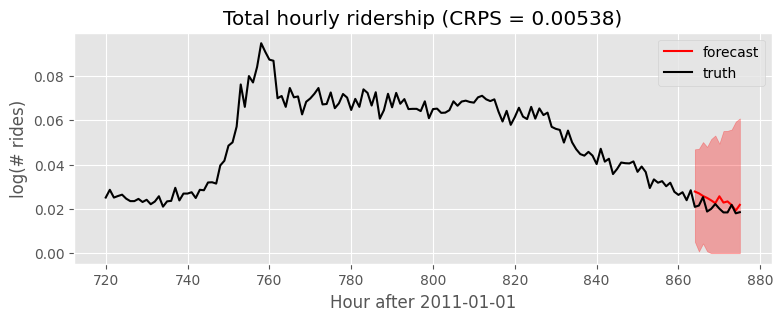

In [21]:
covariates_with_test = torch.zeros(T2-T0, 0)  # empty
samples = forecaster(y[T0:T1,:1], covariates_with_test, num_samples=100)
samples.clamp_(min=0)  # apply domain knowledge: the samples must be positive
p10, p50, p90 = quantile(samples, (0.1, 0.5, 0.9)).squeeze(-1)
crps = eval_crps(samples, y[T1:T2,:1])

plt.figure(figsize=(9, 3))
plt.fill_between(torch.arange(T1, T2), p10, p90, color="red", alpha=0.3)
plt.plot(torch.arange(T1, T2), p50, 'r-', label='forecast')
plt.plot(torch.arange(T1-24*6, T2), y[T1-24*6:T2,:1], 'k-', label='truth')
plt.title("Total hourly ridership (CRPS = {:0.3g})".format(crps))
plt.ylabel("log(# rides)")
plt.xlabel("Hour after 2011-01-01")
plt.legend(loc="best");

That's not too bad. But let's see if we can do better by accouting for the periodic compoenent. We will now implement **Model2**:

\begin{align}
z_t &\sim \mathcal{N}(\beta_1 z_{t-1}, \tau^2)\\
y_t &\sim \mathcal{N}(z_t \color{red} + h_t, \sigma^2)\\
\end{align}

Can you try to implement it? HINT: You can make use of the helper function [periodic_repeat()](http://docs.pyro.ai/en/latest/ops.html#pyro.ops.tensor_utils.periodic_repeat), to repeat the same "historical average pattern" multiple times to match the duration of the training data.

In [22]:
class Model2(ForecastingModel):
    def model(self, zero_data, covariates):
        duration = zero_data.size(-2)
        
        # mean
        mean_prediction = periodic_repeat(historical_average, duration, dim=-1).unsqueeze(-1)# in this version of the model, the mean prediction is just zero - i.e., no periodic component
        
        # On top of this mean prediction, we'll learn a linear dynamical system.
        # This requires specifying five pieces of data, on which we will put structured priors.
        init_dist = dist.Normal(torch.zeros(1), 1).to_event(1) 


        trans_matrix = pyro.sample("timescale", dist.Normal(torch.ones(1,1), 1).to_event(2))
        trans_scale = pyro.sample("trans_scale", dist.HalfNormal(torch.ones(1)).to_event(1)) 

        
        trans_dist = dist.Normal(torch.zeros(1), trans_scale).to_event(1)

        # Note the obs_matrix has shape hidden_dim x obs_dim = 1 x 1.
        obs_matrix = torch.eye(1)
        obs_scale = pyro.sample("obs_scale", dist.HalfNormal(torch.ones(1)).to_event(1)) 
        obs_dist = dist.Normal(torch.zeros(1), obs_scale).to_event(1)

        noise_dist = dist.GaussianHMM(init_dist, trans_matrix, trans_dist, obs_matrix, obs_dist, duration=duration)
        self.predict(noise_dist, mean_prediction)
        

    

And we now perform Bayesian inference on this new version of the model:

In [23]:
%%time
pyro.set_rng_seed(1)
pyro.clear_param_store()
covariates = torch.zeros(T1-T0, 0)  # empty
forecaster = Forecaster(Model2(), y[T0:T1,:1], covariates, learning_rate=0.1, num_steps=500)
for name, value in forecaster.guide.median().items():
    if value.numel() == 1:
        print("{} = {:0.4g}".format(name, value.item()))

INFO 	 step    0 loss = -0.289698
INFO 	 step  100 loss = -2.93796
INFO 	 step  200 loss = -2.94651
INFO 	 step  300 loss = -2.94656
INFO 	 step  400 loss = -2.94562


timescale = 0.8988
trans_scale = 0.005964
obs_scale = 0.009391
CPU times: user 3.44 s, sys: 48.5 ms, total: 3.49 s
Wall time: 3.53 s


And evaluate the results (as we did before for Model 1):

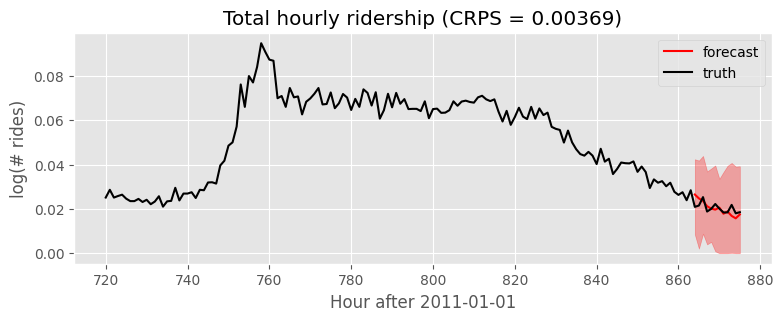

In [24]:
covariates_with_test = torch.zeros(T2-T0, 0)  # empty
samples = forecaster(y[T0:T1,:1], covariates_with_test, num_samples=100)
samples.clamp_(min=0)  # apply domain knowledge: the samples must be positive
p10, p50, p90 = quantile(samples, (0.1, 0.5, 0.9)).squeeze(-1)
crps = eval_crps(samples, y[T1:T2,:1])

plt.figure(figsize=(9, 3))
plt.fill_between(torch.arange(T1, T2), p10, p90, color="red", alpha=0.3)
plt.plot(torch.arange(T1, T2), p50, 'r-', label='forecast')
plt.plot(torch.arange(T1-24*6, T2), y[T1-24*6:T2,:1], 'k-', label='truth')
plt.title("Total hourly ridership (CRPS = {:0.3g})".format(crps))
plt.ylabel("log(# rides)")
plt.xlabel("Hour after 2011-01-01")
plt.legend(loc="best");


Quite better, right? The CRPS score also suggests so.

**Reflection exercise:**
- Think how you could modify the previous model to take into account covariates such as information about special events or weather conditions that could affect the traffic. How would the generative model change? What about the Pyro implementation? 

*Covariates in Model*

*The generative model would change so that y_t = z_t + x_t * β + ε_t (ε_t ∼ 𝒩(0,σ)), where x_t are covariates (e.g., weather or event dummies) and β their coefficients (with priors like 𝒩(0,1)); sample β globally, compute additive/multiplicative effect inside self.time_plate, add to prediction before self.predict.*

*The pyro implementation would extend model(self, zero_data, covariates): sample beta = pyro.sample("beta", dist.Normal(0.,1.).expand([covariates.size(-1)]).to_event(1)), then prediction += (beta * covariates).sum(-1, keepdim=True) or via exposure * feature as in forum examples.*

- How could make this model into an auto-regressive model of higher order (e.g., AR(2))? 

*Replace z_t = z_{t-1} + ε_t with z_t = φ1 * z_{t-1} + φ2 * z_{t-2} + ε_t; sample φ1,φ2 ∼ 𝒩(0,1) (stationarity-constrained), extend GaussianHMM/LinearHMM to order=2 via hidden_dim=2 state [z_t, z_{t-1}], with block transition matrix [[φ1,φ2],].*

- What if you wanted to assume a different distribution for your output variable y other than Gaussian? E.g., a Poisson, in case you were modelling count time-series data. You can have a look at [this example from Pyro](https://pyro.ai/examples/forecasting_i.html) to see how they do it.

*Sample rate = softplus(z_t) or exp(z_t), then use dist.Poisson(rate) for self.predict(noise_dist, prediction) where noise_dist=dist.Poisson(softplus(prediction)); see Pyro's forecasting_i.html for count data via Levy-stable + Poisson, adapting local level to rate parameter.*

- What if you wanted to model a multi-variate time-series? - This one we will actually see in the next notebook.

*Extend obs_dim>1 in zero_data.shape[-1:], hidden_dim as needed; use multivariate GaussianHMM/LinearHMM with full-matrix obs_matrix/trans_matrix (e.g., diagonal for independence); covariates become (duration, features, obs_dim) or shared*

**Additional reading:**
It is highly encouraged that you see the examples of time-series forecasting provided by Pyro:
- [Forecasting I: univariate, heavy tailed](https://pyro.ai/examples/forecasting_i.html)
- [Forecasting II: state space models](https://pyro.ai/examples/forecasting_ii.html)
- [Forecasting III: hierarchical models](https://pyro.ai/examples/forecasting_iii.html)